# Description

Analyzes the LVs driving the association of Niacin with cardiovascular traits using the ARCHS4 CLAMP model.

Mirrors `phenoplier/nbs/30_drug_disease_associations/100-lincs/040-niacin_and_cardiovascular_traits.ipynb`
exactly, replacing MultiPLIER with CLAMP (2366 LVs) and the PhenoPlier `Trait`/`Gene` entity
classes with plain path/DataFrame operations.

Steps:
1. Load per-tissue average-rank predictions from `039-save_full_predictions.ipynb`.
2. For Niacin (DB00627), find the best tissue for each cardiovascular trait (max rank).
3. Standardize scores using all 4091 traits.
4. Select traits above the global 75th percentile.
5. Load CLAMP-projected S-PrediXcan data for the best tissue of each selected trait.
6. Compute per-LV contributions: `drug_trait_predictions[lv, trait] = -1 * drug[lv] * trait[lv]`.
7. Identify common LVs across traits (95th percentile threshold per trait).

**Inputs**:
- `output/drug_disease_analyses/lincs/predictions/full_predictions_by_tissue-rank.h5` (from 039)
- `output/drug_disease_analyses/lincs/lincs-projection.pkl`
- `output/drug_disease_analyses/spredixcan/proj/spredixcan-mashr-zscores-{tissue}-projection.pkl`

**Output**: `output/drug_disease_analyses/lincs/analyses/cardiovascular-niacin.h5`

# Modules loading

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd

from pyprojroot import here

# Settings

In [3]:
# Threshold to select the top-contributing LVs for each selected trait
QUANTILE = 0.95

# Paths

In [4]:
DRUG_DISEASE_DIR = here('output/drug_disease_analyses')

INPUT_PREDICTIONS_FILE = DRUG_DISEASE_DIR / 'lincs' / 'predictions' / 'full_predictions_by_tissue-rank.h5'
display(INPUT_PREDICTIONS_FILE)
assert INPUT_PREDICTIONS_FILE.exists(), (
    f'Run 039-save_full_predictions.ipynb first: {INPUT_PREDICTIONS_FILE}'
)

SPREDIXCAN_PROJ_DIR = DRUG_DISEASE_DIR / 'spredixcan' / 'proj'
display(SPREDIXCAN_PROJ_DIR)
assert SPREDIXCAN_PROJ_DIR.exists()

OUTPUT_DIR = DRUG_DISEASE_DIR / 'lincs' / 'analyses'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
display(OUTPUT_DIR)

OUTPUT_FILEPATH = OUTPUT_DIR / 'cardiovascular-niacin.h5'
display(OUTPUT_FILEPATH)

PosixPath('/home/msubirana/Documents/pivlab/clamp-analyses/output/drug_disease_analyses/lincs/predictions/full_predictions_by_tissue-rank.h5')

PosixPath('/home/msubirana/Documents/pivlab/clamp-analyses/output/drug_disease_analyses/spredixcan/proj')

PosixPath('/home/msubirana/Documents/pivlab/clamp-analyses/output/drug_disease_analyses/lincs/analyses')

PosixPath('/home/msubirana/Documents/pivlab/clamp-analyses/output/drug_disease_analyses/lincs/analyses/cardiovascular-niacin.h5')

# Data loading

## LINCS projection (LVs × drugs)

In [5]:
input_file = DRUG_DISEASE_DIR / 'lincs' / 'lincs-projection.pkl'
display(input_file)
lincs_projection = pd.read_pickle(input_file)
display(lincs_projection.shape)   # (n_lvs, n_drugs)
display(lincs_projection.head())

PosixPath('/home/msubirana/Documents/pivlab/clamp-analyses/output/drug_disease_analyses/lincs/lincs-projection.pkl')

(2366, 1170)

perturbagen,DB00014,DB00091,DB00121,DB00130,DB00131,DB00132,DB00136,DB00140,DB00146,DB00150,...,DB08995,DB09002,DB09004,DB09009,DB09010,DB09015,DB09019,DB09020,DB09022,DB09023
LV1,-0.003664,0.021802,0.050683,-0.023411,0.054818,0.022504,-0.016074,-0.007949,-0.012020,-0.022674,...,-0.051500,-0.039418,-0.021987,0.012250,0.009535,0.012377,0.013959,-0.209899,0.026002,0.009327
LV2,0.011797,0.058622,0.001288,-0.023493,0.009715,0.001838,-0.025821,-0.026784,-0.010831,0.000237,...,-0.003300,-0.000286,0.004965,0.011235,0.002291,-0.003366,-0.002029,-0.067440,0.005340,0.011255
LV3,-0.000841,-0.055107,-0.006764,0.027218,-0.012003,-0.010472,-0.021370,-0.007238,-0.005116,0.005954,...,-0.003723,0.009973,-0.007469,0.009228,-0.010771,-0.017754,0.012783,0.066089,0.008973,-0.011303
LV4,0.031992,-0.511423,-0.071332,-0.059371,-0.035587,-0.033645,-0.076674,0.042806,-0.099315,0.031507,...,0.051060,0.022656,0.054687,0.014682,-0.078138,-0.014696,0.015666,-0.238956,-0.018649,-0.047013
LV5,-0.032510,0.123403,0.005948,0.031886,-0.045581,-0.006246,0.092339,0.034634,0.111000,-0.025291,...,-0.020998,-0.019916,-0.030282,0.009627,0.031024,-0.017982,-0.019684,0.164316,0.012215,-0.027974


# Niacin and cardiovascular diseases

## Select traits

In [6]:
_phenomexcan_traits = [
    'I70_Diagnoses_main_ICD10_I70_Atherosclerosis',
    'CARDIoGRAM_C4D_CAD_ADDITIVE',
    'I25_Diagnoses_main_ICD10_I25_Chronic_ischaemic_heart_disease',
    '20002_1473_Noncancer_illness_code_selfreported_high_cholesterol',
    '6150_100_Vascularheart_problems_diagnosed_by_doctor_None_of_the_above',
    '6150_1_Vascularheart_problems_diagnosed_by_doctor_Heart_attack',
    'I9_CHD_Major_coronary_heart_disease_event',
    'I9_CORATHER_Coronary_atherosclerosis',
    'I9_IHD_Ischaemic_heart_disease_wide_definition',
    'I9_MI_Myocardial_infarction',
    'I21_Diagnoses_main_ICD10_I21_Acute_myocardial_infarction',
    '20002_1075_Noncancer_illness_code_selfreported_heart_attackmyocardial_infarction',
]

_drug_id = 'DB00627'
_drug_name = 'Niacin'

## Get best tissue results for Niacin

For each drug-disease pair, take the maximum prediction value across all 49 tissues.
This selects the tissue that maximizes the prediction score — the presumed "most causal" tissue.

This matches PhenoPlier's approach exactly.

In [7]:
# Load Niacin column from each tissue
drugs_tissue_df = {}

with pd.HDFStore(INPUT_PREDICTIONS_FILE, mode='r') as store:
    for tk in store.keys():
        tissue_name = tk.lstrip('/')  # remove leading '/'
        df = store[tk][_drug_id]
        drugs_tissue_df[tissue_name] = df

display(f'Tissues loaded: {len(drugs_tissue_df)}')

'Tissues loaded: 49'

In [8]:
# DataFrame: traits × tissues with Niacin prediction scores
_tmp = pd.DataFrame(drugs_tissue_df)
display(_tmp.shape)   # (4091, 49)
display(_tmp.head())

(4091, 49)

,Adipose_Subcutaneous,Adipose_Visceral_Omentum,Adrenal_Gland,Artery_Aorta,Artery_Coronary,Artery_Tibial,Brain_Amygdala,Brain_Anterior_cingulate_cortex_BA24,Brain_Caudate_basal_ganglia,Brain_Cerebellar_Hemisphere,...,Skin_Not_Sun_Exposed_Suprapubic,Skin_Sun_Exposed_Lower_leg,Small_Intestine_Terminal_Ileum,Spleen,Stomach,Testis,Thyroid,Uterus,Vagina,Whole_Blood
100001_raw_Food_weight,3392746.0,3776155.25,3583585.50,1.336091e+06,2626119.00,2526845.25,3260770.5,3851308.75,3124604.75,2964017.500,...,1884345.375,1892162.00,4120564.75,4188480.000,4390771.00,1910477.625,2621468.50,3181958.50,2767050.50,4470233.000
100002_raw_Energy,3600481.5,4251819.00,2986178.50,9.300802e+05,3630847.25,1844201.00,4211517.0,2689283.00,4380216.00,4227349.000,...,2000214.750,3804873.50,2943841.00,3284398.500,3963154.75,3076215.500,3664352.75,4151164.00,4421494.00,1928717.625
100003_raw_Protein,1579186.0,3540723.50,2770285.50,1.461815e+06,4244612.00,2174034.50,4544980.0,3694024.00,4279547.50,3822263.250,...,3332070.250,3151217.75,3160224.50,2380020.500,4497509.00,1078509.750,2904178.50,4385022.50,3614248.50,1588678.000
100004_raw_Fat,3727552.5,4603329.00,1410600.25,1.336947e+06,3866690.50,2487110.25,4225630.5,2493454.00,4284631.00,3477480.750,...,1354971.250,3091179.00,2871953.50,3319650.000,2761113.00,3187744.750,2997013.50,3670537.25,1633554.00,2733752.500
100005_raw_Carbohydrate,3045767.5,2140988.50,2110510.75,1.391417e+06,1804599.75,1176202.25,3404865.5,2368043.50,3409619.25,1924422.375,...,2093018.375,2496621.25,2022616.75,1166738.375,3000784.25,1739706.750,2108546.75,2500507.25,3009151.75,3063658.250


In [9]:
# Best tissue per cardiovascular trait (highest Niacin prediction)
traits_best_tissues_df = pd.DataFrame(drugs_tissue_df).loc[_phenomexcan_traits].idxmax(axis=1)
display(traits_best_tissues_df)

I70_Diagnoses_main_ICD10_I70_Atherosclerosis                                                        Esophagus_Muscularis
CARDIoGRAM_C4D_CAD_ADDITIVE                                                                                       Spleen
I25_Diagnoses_main_ICD10_I25_Chronic_ischaemic_heart_disease                                               Colon_Sigmoid
20002_1473_Noncancer_illness_code_selfreported_high_cholesterol                              Brain_Cerebellar_Hemisphere
6150_100_Vascularheart_problems_diagnosed_by_doctor_None_of_the_above               Brain_Anterior_cingulate_cortex_BA24
6150_1_Vascularheart_problems_diagnosed_by_doctor_Heart_attack                                      Adipose_Subcutaneous
I9_CHD_Major_coronary_heart_disease_event                                                          Breast_Mammary_Tissue
I9_CORATHER_Coronary_atherosclerosis                                                                       Colon_Sigmoid
I9_IHD_Ischaemic_heart_disease_w

In [10]:
# Maximum Niacin score across all tissues per trait
drug_df = pd.DataFrame(drugs_tissue_df).max(axis=1)  # (4091,)
display(drug_df.shape)
display(drug_df.describe())

(4091,)

count    4.091000e+03
mean     4.259839e+06
std      3.094153e+05
min      2.772810e+06
25%      4.086876e+06
50%      4.334773e+06
75%      4.493852e+06
max      4.769176e+06
dtype: float64

In [11]:
# Standardize using all 4091 traits
drug_mean, drug_std = drug_df.mean(), drug_df.std()
display((drug_mean, drug_std))

drug_df_stats = ((drug_df - drug_mean) / drug_std).describe()
display(drug_df_stats)

(np.float32(4.259839e+06), np.float32(309415.3))

count    4091.000000
mean        0.000001
std         1.000000
min        -4.805934
25%        -0.559001
50%         0.242179
75%         0.756308
max         1.646129
dtype: float64

In [12]:
# Standardized Niacin scores for cardiovascular traits
drug_df_cardio = (drug_df.loc[_phenomexcan_traits] - drug_mean) / drug_std
display(drug_df_cardio.sort_values())

I70_Diagnoses_main_ICD10_I70_Atherosclerosis                                       -0.945326
6150_1_Vascularheart_problems_diagnosed_by_doctor_Heart_attack                     -0.107839
20002_1075_Noncancer_illness_code_selfreported_heart_attackmyocardial_infarction    0.152226
CARDIoGRAM_C4D_CAD_ADDITIVE                                                         0.329473
I21_Diagnoses_main_ICD10_I21_Acute_myocardial_infarction                            0.630596
I9_MI_Myocardial_infarction                                                         0.711849
I9_CHD_Major_coronary_heart_disease_event                                           0.843216
I25_Diagnoses_main_ICD10_I25_Chronic_ischaemic_heart_disease                        1.061163
I9_CORATHER_Coronary_atherosclerosis                                                1.144856
20002_1473_Noncancer_illness_code_selfreported_high_cholesterol                     1.191893
I9_IHD_Ischaemic_heart_disease_wide_definition                        

In [13]:
# Select traits for which Niacin has a high prediction (above global 75th percentile)
selected_traits = drug_df_cardio[drug_df_cardio > drug_df_stats['75%']].index.tolist()
display(f'Selected traits: {len(selected_traits)}')
display(selected_traits)

'Selected traits: 6'

['I25_Diagnoses_main_ICD10_I25_Chronic_ischaemic_heart_disease',
 '20002_1473_Noncancer_illness_code_selfreported_high_cholesterol',
 '6150_100_Vascularheart_problems_diagnosed_by_doctor_None_of_the_above',
 'I9_CHD_Major_coronary_heart_disease_event',
 'I9_CORATHER_Coronary_atherosclerosis',
 'I9_IHD_Ischaemic_heart_disease_wide_definition']

## Get Niacin projection values

In [14]:
# Niacin LV vector: (n_lvs,) — rows = LVs, columns = drugs → take drug column → transpose
drug_data = lincs_projection[_drug_id]  # Series indexed by LV
display(drug_data.shape)
display(drug_data.head())

(2366,)

LV1    0.018649
LV2    0.023365
LV3   -0.024412
LV4    0.079144
LV5   -0.082024
Name: DB00627, dtype: float64

## Gene module-based — LVs driving association

For each selected trait, load the CLAMP-projected S-PrediXcan data from the best tissue
(identified by maximum Niacin prediction in the previous step).

In [15]:
traits_lv_data = []

for trait in selected_traits:
    best_tissue = traits_best_tissues_df.loc[trait]
    display(f'{trait} → best tissue: {best_tissue}')

    proj_file = SPREDIXCAN_PROJ_DIR / f'spredixcan-mashr-zscores-{best_tissue}-projection.pkl'
    assert proj_file.exists(), f'Projection file not found: {proj_file}'

    # Load tissue projection: index=LVs, columns=traits → select this trait
    trait_lv_vec = pd.read_pickle(proj_file)[trait]
    traits_lv_data.append(trait_lv_vec)

'I25_Diagnoses_main_ICD10_I25_Chronic_ischaemic_heart_disease → best tissue: Colon_Sigmoid'

'20002_1473_Noncancer_illness_code_selfreported_high_cholesterol → best tissue: Brain_Cerebellar_Hemisphere'

'6150_100_Vascularheart_problems_diagnosed_by_doctor_None_of_the_above → best tissue: Brain_Anterior_cingulate_cortex_BA24'

'I9_CHD_Major_coronary_heart_disease_event → best tissue: Breast_Mammary_Tissue'

'I9_CORATHER_Coronary_atherosclerosis → best tissue: Colon_Sigmoid'

'I9_IHD_Ischaemic_heart_disease_wide_definition → best tissue: Heart_Atrial_Appendage'

In [16]:
# Combine: rows = LVs, columns = selected traits
module_tissue_data = pd.DataFrame(traits_lv_data).T
display(module_tissue_data.shape)   # (n_lvs, n_selected_traits)
display(module_tissue_data.head())

(2366, 6)

,I25_Diagnoses_main_ICD10_I25_Chronic_ischaemic_heart_disease,20002_1473_Noncancer_illness_code_selfreported_high_cholesterol,6150_100_Vascularheart_problems_diagnosed_by_doctor_None_of_the_above,I9_CHD_Major_coronary_heart_disease_event,I9_CORATHER_Coronary_atherosclerosis,I9_IHD_Ischaemic_heart_disease_wide_definition
LV1,0.001922,0.034451,0.016842,0.010487,-0.000877,0.005772
LV2,0.003029,0.007214,0.035448,-0.004054,-0.003185,-0.018915
LV3,0.014509,-0.017883,-0.003346,0.046315,0.016969,0.032030
LV4,0.016255,-0.002314,-0.016253,0.024326,0.009356,0.017181
LV5,-0.007862,0.045440,0.021266,-0.013670,-0.003546,-0.007629


In [17]:
# Sanity check: prediction scores should match dot-product
_check = (-1.0 * drug_data.dot(module_tissue_data)).sort_values(ascending=False)
display(_check)

6150_100_Vascularheart_problems_diagnosed_by_doctor_None_of_the_above    0.053630
20002_1473_Noncancer_illness_code_selfreported_high_cholesterol          0.033785
I9_IHD_Ischaemic_heart_disease_wide_definition                           0.025188
I9_CORATHER_Coronary_atherosclerosis                                     0.018464
I25_Diagnoses_main_ICD10_I25_Chronic_ischaemic_heart_disease             0.015944
I9_CHD_Major_coronary_heart_disease_event                                0.013800
Name: DB00627, dtype: float64

In [18]:
# Per-LV contribution: drug_trait_predictions[lv, trait] = -1 * drug[lv] * trait[lv]
drug_trait_predictions = pd.DataFrame(
    -1.0 * (drug_data.values[:, None] * module_tissue_data.values),
    columns=module_tissue_data.columns.copy(),
    index=drug_data.index.copy(),
)
display(drug_trait_predictions.shape)   # (n_lvs, n_selected_traits)
display(drug_trait_predictions.head())

(2366, 6)

,I25_Diagnoses_main_ICD10_I25_Chronic_ischaemic_heart_disease,20002_1473_Noncancer_illness_code_selfreported_high_cholesterol,6150_100_Vascularheart_problems_diagnosed_by_doctor_None_of_the_above,I9_CHD_Major_coronary_heart_disease_event,I9_CORATHER_Coronary_atherosclerosis,I9_IHD_Ischaemic_heart_disease_wide_definition
LV1,-0.000036,-0.000642,-0.000314,-0.000196,0.000016,-0.000108
LV2,-0.000071,-0.000169,-0.000828,0.000095,0.000074,0.000442
LV3,0.000354,-0.000437,-0.000082,0.001131,0.000414,0.000782
LV4,-0.001287,0.000183,0.001286,-0.001925,-0.000740,-0.001360
LV5,-0.000645,0.003727,0.001744,-0.001121,-0.000291,-0.000626


## Get common LVs across selected traits

In [19]:
display(QUANTILE)

0.95

In [20]:
common_lvs = []

for trait in drug_trait_predictions.columns:
    _tmp = drug_trait_predictions[trait]

    # For each trait, get LVs with positive contribution above the quantile threshold
    _tmp = _tmp[_tmp > 0.0]
    q = _tmp.quantile(QUANTILE)
    _tmp = _tmp[_tmp > q]
    display(f'Trait: {trait}')
    display(f'Number of LVs: {_tmp.shape[0]}')

    _tmp = _tmp.sort_values(ascending=False)
    common_lvs.append(_tmp)

    display(_tmp.head(20))
    print()

'Trait: I25_Diagnoses_main_ICD10_I25_Chronic_ischaemic_heart_disease'

'Number of LVs: 59'

LV1485    0.013965
LV529     0.003461
LV1945    0.002846
LV1341    0.001582
LV609     0.001547
LV2140    0.001531
LV581     0.001500
LV134     0.001481
LV1980    0.001466
LV313     0.001410
LV272     0.001397
LV2290    0.001345
LV36      0.001255
LV85      0.001251
LV82      0.001197
LV153     0.001111
LV199     0.001090
LV236     0.001074
LV1443    0.001056
LV131     0.001049
Name: I25_Diagnoses_main_ICD10_I25_Chronic_ischaemic_heart_disease, dtype: float64

'Trait: 20002_1473_Noncancer_illness_code_selfreported_high_cholesterol'

'Number of LVs: 61'

...

'Number of LVs: 59'

LV1485    0.014267
LV529     0.003280
LV1945    0.002880
LV272     0.001728
LV609     0.001539
LV581     0.001501
LV1341    0.001481
LV236     0.001422
LV313     0.001370
LV131     0.001350
LV2140    0.001336
LV1980    0.001321
LV199     0.001293
LV134     0.001252
LV543     0.001163
LV82      0.001135
LV1692    0.001070
LV2290    0.000998
LV153     0.000993
LV85      0.000944
Name: I9_CORATHER_Coronary_atherosclerosis, dtype: float64

'Trait: I9_IHD_Ischaemic_heart_disease_wide_definition'

'Number of LVs: 61'

LV1485    0.014610
LV36      0.004774
LV418     0.003495
LV153     0.002909
LV705     0.002576
LV272     0.002054
LV380     0.001945
LV134     0.001913
LV1979    0.001759
LV506     0.001714
LV1945    0.001543
LV1055    0.001520
LV1961    0.001427
LV1341    0.001375
LV82      0.001267
LV581     0.001259
LV254     0.001238
LV543     0.001195
LV1475    0.001128
LV2051    0.001125
Name: I9_IHD_Ischaemic_heart_disease_wide_definition, dtype: float64

In [21]:
common_lvs_df = (
    pd.concat(common_lvs)
    .reset_index()
    .rename(columns={'index': 'lv', 0: 'value'})
)
display(common_lvs_df.shape)
display(common_lvs_df.head())

(359, 2)

,lv,value
0,LV1485,0.013965
1,LV529,0.003461
2,LV1945,0.002846
3,LV1341,0.001582
4,LV609,0.001547


In [22]:
# Group by LV and sum contributions across traits
lvs_by_sum = common_lvs_df.groupby('lv')['value'].sum().sort_values(ascending=False)
display(lvs_by_sum.head(25))

lv
LV1485    0.058596
LV1563    0.016984
LV36      0.010939
LV529     0.009592
LV581     0.007889
LV156     0.007716
LV134     0.007552
LV1961    0.007506
LV1945    0.007269
LV705     0.007084
LV153     0.006676
LV2287    0.005511
LV5       0.005471
LV66      0.005456
LV313     0.005367
LV418     0.005289
LV272     0.005180
LV267     0.005095
LV199     0.004890
LV84      0.004860
LV83      0.004818
LV754     0.004746
LV131     0.004721
LV339     0.004490
LV1341    0.004438
Name: value, dtype: float64

In [23]:
# Group by LV and count how many traits they appear in
lvs_by_count = common_lvs_df.groupby('lv')['value'].count().sort_values(ascending=False)
display(lvs_by_count.head(25))

lv
LV134     6
LV581     6
LV36      5
LV1485    5
LV529     5
LV1443    4
LV290     4
LV339     4
LV2197    4
LV153     4
LV131     4
LV125     4
LV236     4
LV313     4
LV83      4
LV84      4
LV465     4
LV543     4
LV754     4
LV2009    3
LV1945    3
LV199     3
LV1233    3
LV1692    3
LV1341    3
Name: value, dtype: int64

# Visualization

Heatmap of per-LV contributions to Niacin–cardiovascular trait associations for the top 20 LVs (ranked by total contribution across traits).
Each cell shows `−drug[LV] × trait[LV]`; positive values (red) indicate that the LV drives the predicted association.

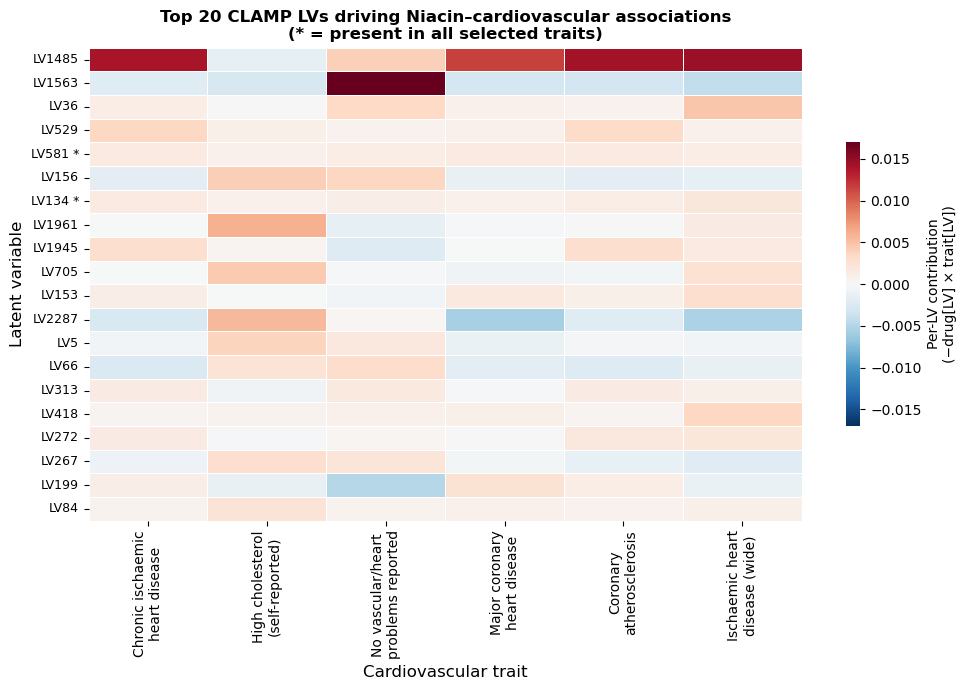

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

TRAIT_SHORT_LABELS = {
    'I25_Diagnoses_main_ICD10_I25_Chronic_ischaemic_heart_disease':
        'Chronic ischaemic\nheart disease',
    '20002_1473_Noncancer_illness_code_selfreported_high_cholesterol':
        'High cholesterol\n(self-reported)',
    '6150_100_Vascularheart_problems_diagnosed_by_doctor_None_of_the_above':
        'No vascular/heart\nproblems reported',
    'I9_CHD_Major_coronary_heart_disease_event':
        'Major coronary\nheart disease',
    'I9_CORATHER_Coronary_atherosclerosis':
        'Coronary\natherosclerosis',
    'I9_IHD_Ischaemic_heart_disease_wide_definition':
        'Ischaemic heart\ndisease (wide)',
}

TOP_N = 20
top_lvs = lvs_by_sum.head(TOP_N).index.tolist()

heatmap_data = drug_trait_predictions.loc[top_lvs].rename(columns=TRAIT_SHORT_LABELS)

# Annotate LVs that appear in all traits
lv_counts = common_lvs_df.groupby('lv')['value'].count()
n_traits = drug_trait_predictions.shape[1]
universal_lvs = set(lv_counts[lv_counts == n_traits].index)
yticklabels = [
    f'{lv} *' if lv in universal_lvs else lv
    for lv in top_lvs
]

abs_max = heatmap_data.abs().max().max()

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-abs_max,
    vmax=abs_max,
    linewidths=0.5,
    linecolor='white',
    robust=False,
    yticklabels=yticklabels,
    cbar_kws={'label': 'Per-LV contribution\n(−drug[LV] × trait[LV])', 'shrink': 0.6},
)

ax.set_xlabel('Cardiovascular trait', fontsize=12)
ax.set_ylabel('Latent variable', fontsize=12)
ax.set_title(
    f'Top {TOP_N} CLAMP LVs driving Niacin–cardiovascular associations\n'
    '(* = present in all selected traits)',
    fontsize=12, fontweight='bold',
)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

## LV biological annotations (pathways and traits)

For each of the top LVs driving the Niacin–cardiovascular associations, show:
- **Left panel**: enriched biological pathways (from the ARCHS4 CLAMP summary; FDR < 0.1, AUC > 0.6). Point size = AUC, color = −log₁₀(FDR).
- **Right panel**: associated human traits from PhenomeXcan (FDR < 0.05). Point size = sample size N, color = −log₁₀(FDR).

In [25]:
import re
import textwrap
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

_readRDS = ro.r["readRDS"]

# ─── Pathway enrichment (archs4_CLAMP_C2CP summary slot) ──────────────────────
_rds = _readRDS(str(here("output/archs4/archs4_CLAMP_C2CP.rds")))
with localconverter(ro.default_converter + pandas2ri.converter):
    _summary_df = ro.conversion.rpy2py(_rds.rx2("summary"))
_rds = None

_summary_df["FDR"] = pd.to_numeric(_summary_df["FDR"], errors="coerce")
_summary_df["AUC"] = pd.to_numeric(_summary_df["AUC"], errors="coerce")
pathway_sig = _summary_df[(_summary_df["FDR"] < 0.1) & (_summary_df["AUC"] > 0.6)].copy()
display(f"Significant pathways: {pathway_sig.shape}")

# ─── Trait associations (archs4-phenoplier) ────────────────────────────────────
_traits_rds = _readRDS(str(here("data/archs4/traits/archs4-phenoplier.rds")))
with localconverter(ro.default_converter + pandas2ri.converter):
    _traits_df = ro.conversion.rpy2py(_traits_rds)

if "phenotype_desc" in _traits_df.columns:
    _traits_df = _traits_df.drop(columns=["phenotype"], errors="ignore")
    _traits_df = _traits_df.rename(columns={"phenotype_desc": "phenotype"})
_traits_df = _traits_df.rename(columns={"lv": "LV", "fdr": "FDR"})
traits_sig = _traits_df[_traits_df["FDR"] < 0.05].copy()
display(f"Significant trait associations: {traits_sig.shape}")

# ─── Phenotype sample sizes ────────────────────────────────────────────────────
_pheno = pd.read_csv(
    here("output/gtex/phenomexcan_simplified_phenotypes_info.tsv.gz"),
    sep="\t",
)
for _col in ["n", "n_cases", "n_controls"]:
    if _col in _pheno.columns:
        _pheno[_col] = pd.to_numeric(_pheno[_col], errors="coerce")

_pheno["n_eff"] = _pheno["n"].combine_first(
    _pheno.get("n_cases", pd.Series(dtype=float)).fillna(0)
    + _pheno.get("n_controls", pd.Series(dtype=float)).fillna(0)
)
_pheno["n_eff"] = _pheno["n_eff"].replace(0.0, float("nan"))

desc_to_n = (
    _pheno.dropna(subset=["n_eff"])
    .groupby("description")["n_eff"]
    .max()
    .reset_index()
    .rename(columns={"description": "phenotype"})
)
display(f"Phenotype sizes loaded: {desc_to_n.shape}")

'Significant pathways: (760, 7)'

'Significant trait associations: (8456, 4)'

/tmp/ipykernel_2576769/2604012062.py:41: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  _pheno["n_eff"] = _pheno["n"].combine_first(


'Phenotype sizes loaded: (4034, 2)'

"LVs to annotate: ['LV1485', 'LV1563', 'LV36', 'LV529', 'LV581', 'LV156', 'LV134', 'LV1961', 'LV1945', 'LV705', 'LV153', 'LV2287', 'LV5', 'LV66', 'LV313', 'LV272', 'LV267', 'LV84', 'LV83', 'LV754']"

/tmp/ipykernel_2576769/523166757.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


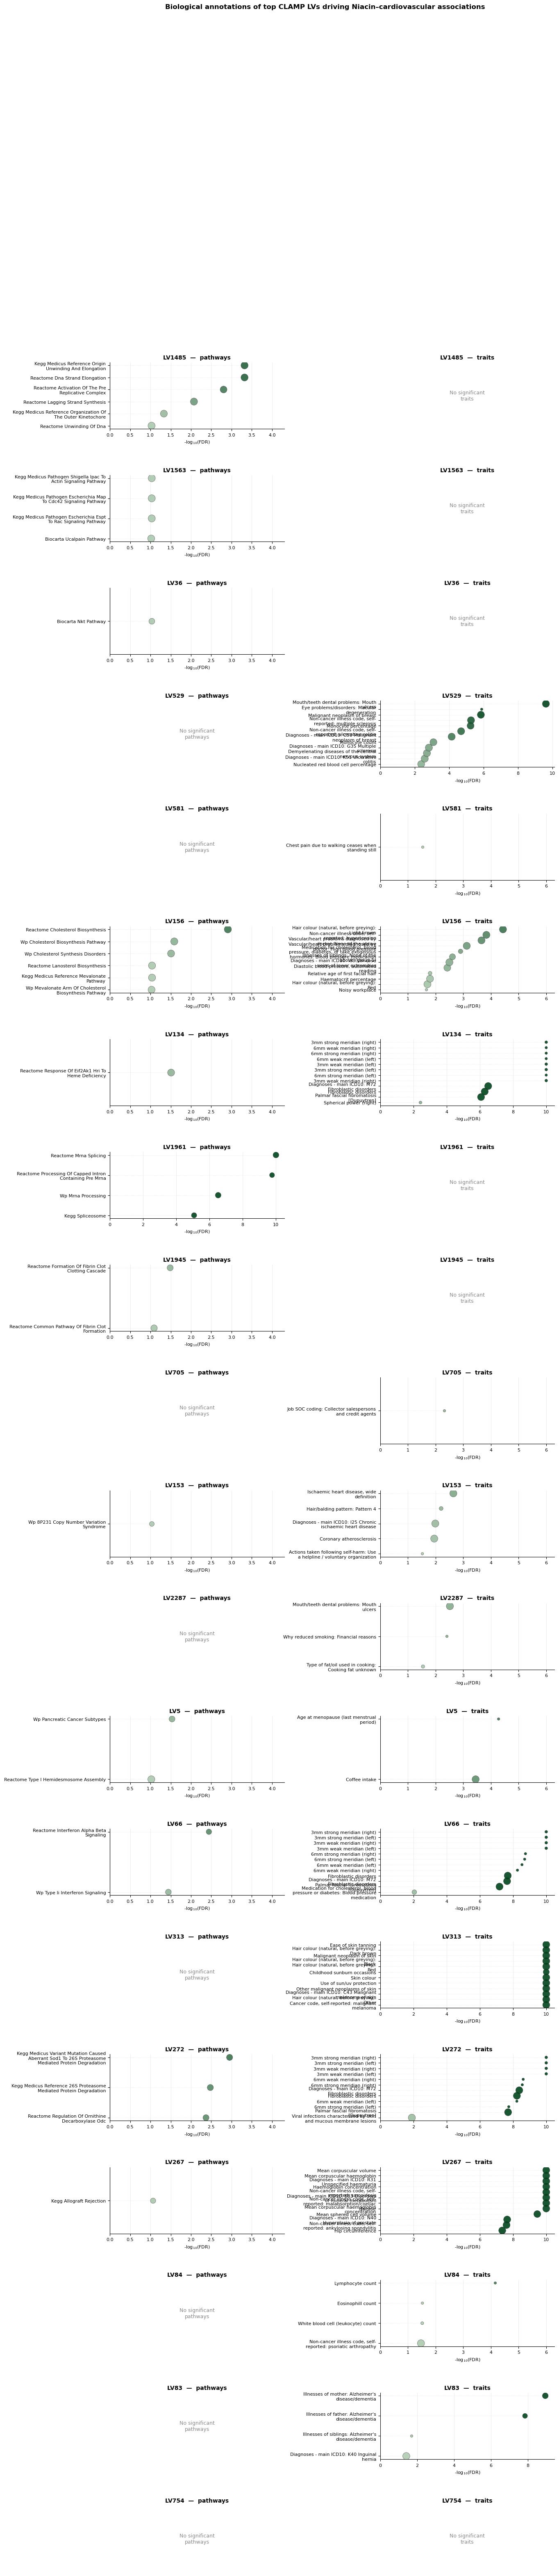

In [31]:
import matplotlib.colors as mcolors

GREEN_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "green_sig", ["#e5f5e0", "#00441b"]
)

def _clean_pathway_label(s, width=38):
    for prefix in ["C2CP_", "REACTOME_", "KEGG_MEDICUS_REFERENCE_", "KEGG_", "WP_"]:
        if s.startswith(prefix):
            s = s[len(prefix):]
            break
    return "\n".join(textwrap.wrap(s.replace("_", " ").title(), width=width))


def _lollipop_panel(ax, df, x_col, y_col, size_col, fdr_max,
                    size_range=(20, 160), size_limits=None, max_rows=12):
    """Lollipop dot plot: dotted connectors + scatter with size & color encoding."""
    if len(df) == 0:
        ax.text(0.5, 0.5, "No significant\nassociations",
                ha="center", va="center", transform=ax.transAxes,
                fontsize=9, color="#888888")
        ax.axis("off")
        return

    df = df.sort_values(x_col, ascending=True).tail(max_rows).reset_index(drop=True)
    y = np.arange(len(df))
    x_raw = df[x_col].values
    x_cap = np.minimum(x_raw, fdr_max)

    ax.hlines(y, 0, x_raw, colors="#d0d0d0", linewidth=0.4, linestyles="dotted")

    sv = df[size_col].values.astype(float) if size_col in df.columns else np.ones(len(df))
    lo, hi = size_limits if size_limits else (np.nanmin(sv), np.nanmax(sv))
    sizes = np.clip(
        (sv - lo) / max(hi - lo, 1e-9) * (size_range[1] - size_range[0]) + size_range[0],
        size_range[0], size_range[1],
    )

    ax.scatter(x_raw, y, s=sizes, c=x_cap, cmap=GREEN_CMAP, vmin=0, vmax=fdr_max,
               edgecolors="#333333", linewidths=0.4, alpha=0.9, zorder=3)

    ax.set_yticks(y)
    ax.set_yticklabels(df[y_col].values, fontsize=8)
    ax.set_xlim(0, max(fdr_max + 0.3, x_raw.max() + 0.5))
    ax.set_xlabel("-log$_{10}$(FDR)", fontsize=8)
    ax.tick_params(axis="x", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", color="#dddddd", linewidth=0.4)
    ax.set_axisbelow(True)


# ─── Select top LVs that have at least one annotation ────────────────────────
SHOW_N_LVS = 20
MAX_ROWS   = 12
FDR_MAX_PW = 4
FDR_MAX_TR = 6

lv_show = [
    lv for lv in lvs_by_sum.index
    if (pathway_sig["LV"] == lv).any() or (traits_sig["LV"] == lv).any()
][:SHOW_N_LVS]

display(f"LVs to annotate: {lv_show}")

n_rows = len(lv_show)
fig, axes = plt.subplots(
    n_rows, 2,
    figsize=(14, 3.5 * n_rows),
    gridspec_kw={"wspace": 0.55, "hspace": 0.7},
)
if n_rows == 1:
    axes = [axes]

for row, lv in enumerate(lv_show):
    ax_pw, ax_tr = axes[row]

    # ── Pathways ──────────────────────────────────────────────────────────────
    pw = pathway_sig[pathway_sig["LV"] == lv].copy()
    if len(pw):
        pw["neg_log10_FDR"] = -np.log10(np.maximum(pw["FDR"], 1e-10))
        pw["label"] = pw["pathway"].apply(_clean_pathway_label)
        _lollipop_panel(ax_pw, pw, "neg_log10_FDR", "label", "AUC",
                        fdr_max=FDR_MAX_PW, size_limits=(0.6, 1.0))
    else:
        ax_pw.text(0.5, 0.5, "No significant\npathways",
                   ha="center", va="center", transform=ax_pw.transAxes,
                   fontsize=9, color="#888888")
        ax_pw.axis("off")
    ax_pw.set_title(f"{lv}  —  pathways", fontsize=10, fontweight="bold")

    # ── Traits ────────────────────────────────────────────────────────────────
    tr = traits_sig[traits_sig["LV"] == lv].merge(desc_to_n, on="phenotype", how="left")
    tr = tr.dropna(subset=["n_eff"]).copy()
    if len(tr):
        tr["neg_log10_FDR"] = -np.log10(np.maximum(tr["FDR"], 1e-10))
        tr["label"] = tr["phenotype"].apply(
            lambda s: "\n".join(
                textwrap.wrap(re.sub(r"\s+", " ", str(s).replace("_", " ")), width=38)
            )
        )
        nv = tr["n_eff"].values
        _lollipop_panel(ax_tr, tr, "neg_log10_FDR", "label", "n_eff",
                        fdr_max=FDR_MAX_TR, size_limits=(nv.min(), nv.max()))
    else:
        ax_tr.text(0.5, 0.5, "No significant\ntraits",
                   ha="center", va="center", transform=ax_tr.transAxes,
                   fontsize=9, color="#888888")
        ax_tr.axis("off")
    ax_tr.set_title(f"{lv}  —  traits", fontsize=10, fontweight="bold")

fig.suptitle(
    "Biological annotations of top CLAMP LVs driving Niacin–cardiovascular associations",
    fontsize=12, fontweight="bold", y=1.005,
)
plt.tight_layout()
plt.show()

# Which are the top LVs "affected" by Niacin?

In [27]:
# LVs with largest absolute values in Niacin's CLAMP projection
drug_data.abs().sort_values(ascending=False).head(30)

LV1485    0.201619
LV1563    0.165625
LV2287    0.146222
LV341     0.136739
LV36      0.128289
LV866     0.117337
LV199     0.113160
LV66      0.109456
LV1272    0.105723
LV1433    0.100992
LV134     0.099038
LV9       0.094707
LV705     0.083049
LV331     0.082300
LV5       0.082024
LV2100    0.080613
LV4       0.079144
LV269     0.075834
LV146     0.073806
LV156     0.072877
LV1961    0.072443
LV107     0.067340
LV86      0.063346
LV380     0.060627
LV267     0.060617
LV1422    0.060288
LV2337    0.060237
LV1341    0.059912
LV671     0.058133
LV138     0.054485
Name: DB00627, dtype: float64

In [28]:
# Top LVs with positive values (Niacin upregulates these programs)
drug_data.sort_values(ascending=False).head(15)

LV1485    0.201619
LV341     0.136739
LV199     0.113160
LV66      0.109456
LV9       0.094707
LV331     0.082300
LV2100    0.080613
LV4       0.079144
LV269     0.075834
LV107     0.067340
LV267     0.060617
LV1422    0.060288
LV1341    0.059912
LV671     0.058133
LV85      0.054465
Name: DB00627, dtype: float64

In [29]:
# Top LVs with negative values (Niacin downregulates these programs)
drug_data.sort_values(ascending=True).head(15)

LV1563   -0.165625
LV2287   -0.146222
LV36     -0.128289
LV866    -0.117337
LV1272   -0.105723
LV1433   -0.100992
LV134    -0.099038
LV705    -0.083049
LV5      -0.082024
LV146    -0.073806
LV156    -0.072877
LV1961   -0.072443
LV86     -0.063346
LV380    -0.060627
LV2337   -0.060237
Name: DB00627, dtype: float64

# Save

In [30]:
with pd.HDFStore(OUTPUT_FILEPATH, mode='w', complevel=4) as store:
    store.put('traits_module_tissue_data', module_tissue_data, format='fixed')
    store.put('drug_data', drug_data, format='fixed')
    store.put('drug_trait_predictions', drug_trait_predictions, format='fixed')
    store.put('common_lvs', common_lvs_df, format='fixed')

print(f'Saved to: {OUTPUT_FILEPATH}')

Saved to: /home/msubirana/Documents/pivlab/clamp-analyses/output/drug_disease_analyses/lincs/analyses/cardiovascular-niacin.h5
